# 20 — Population-Facility-Land Closure 人口-设施-用地平衡

**Core question**: 一个居住区的「人口 — 配套设施 — 用地」三者如何互相
校验？给定用地和容积率，人口估计是否自洽？千人指标要求的设施用地是否
配足？人均用地是否落在 GB 50180-2018 的参考带内？

**Answer**: 三条互相独立的检验路径闭合在同一个恒等式上 ——
`人口 = 住宅建筑面积 / 人均建筑面积 = 居住用地 × FAR / 人均建筑面积`。
M1（千人指标）把人口换算成设施需求，M2（人均用地）把用地换算成人均
水平，M3（人口容量）把容积率换算成可承载人口。三者闭合则方案成立；
任一处断裂即输出可定位的缺口 / 富余 / 过密 / 低密度清单。

## 0. Background — 千人指标、人口-设施-用地平衡

《城市居住区规划设计标准》GB 50180-2018 通过"千人指标"把**人口规模**
与**配套设施**绑定：按每千名居民应配建的设施建筑面积与用地面积控制
（配套设置要求见附录B，控制指标为第5章表5.0.3 —— 通称"千人指标"；
旧版 GB 50180-93 中位于附录A，故实践中常称"附录A 千人指标"）。

标准将居住区按人口分级：十五分钟生活圈（5-10万人）、十分钟生活圈
（1.5-2.5万人）、五分钟生活圈（0.5-1.2万人）、居住街坊（0.1-0.3万人）。
各级指标**不累计**（十五分钟圈指标不含十分钟圈指标，以此类推），
计算完整居住区时应分层级叠加。

本 notebook 用三种方法对同一块模拟场地做闭合校验：

| 方法 | 输入 | 输出 | 校验对象 |
|---|---|---|---|
| M1 千人指标交叉校验 | 居住用地×FAR → 人口 → 千人指标 | 各设施 需求/已配/差额 | 设施配建数量与用地 |
| M2 人均用地平衡 | 用地汇总 ÷ 人口 | 人均用地 vs 参考带 | 用地结构（居住/绿地/设施） |
| M3 人口容量校验 | 各片区 用地+FAR+规划人口 | 容量 vs 规划，过密/低密度 | 密度与人口规模 |

> 本 notebook 对应探索目标 **B-04 (人口-设施-用地平衡)**。
> 千人指标为参数敏感（C 类）分析：表5.0.3 数值以标准原文为准，
> 本演示用参考值见 1.1 节，正式使用须与规划主管部门标定并写入
> assumptions.json。

## 1. Method 1 — 千人指标 cross-check 千人指标交叉校验

两步闭合：

1. **人口估计**：`人口 = 居住用地 × FAR ÷ 人均建筑面积`。
   GB 50180-2018 条文说明 4.0.2/4.0.3 明确各项用地指标"按人均住房建筑
   面积 35 m² 的标准进行计算" —— 这是本方法唯一的标准锚点。
2. **设施需求**：`设施需求用地 = 人口 ÷ 1000 × 千人指标(用地)`，
   与已配设施用地比较 → 每类设施的 盈余 / 缺口。

千人指标只校验"配多少"，不校验"放不放得下" —— 用地总量与人均水平
由 M2 / M3 负责。

### 1.1 千人指标参考值

表5.0.3 的精确数值为图版，无法从公开文本直接引用；下表按条文说明中
的锚点（学校规模、派出所 32~40 m²/千人）推导，作为**演示用参考值**
（C 类参数，正式项目须以标准原文分圈层叠加计算并标定）：

| 设施类别 | 用地 m²/千人 | 建筑面积 m²/千人 | 推导锚点 |
|---|---|---|---|
| 教育·初中 | 950 | 640 | 条文说明：十五分钟圈 2×24班~1×24+2×36班 初中；生均用地~22 m²、每班45人 |
| 教育·小学 | 1950 | 1320 | 十分钟圈 36~54班 小学；生均~20 m² |
| 教育·幼儿园 | 650 | 440 | 五分钟圈 12~18班 幼儿园；生均~13 m² |
| 医疗卫生 | 60 | 60 | 社区卫生服务中心 3000~5000 m² / 5~10万人 |
| 养老设施 | 120 | 100 | 老年养护院 6000~10000 m² / 5~10万人 |
| 文化设施 | 120 | 110 | 文化活动中心 6000~10000 m² / 5~10万人 |
| 体育设施 | 200 | 60 | 大型多功能运动场地 10000~20000 m² / 5~10万人 |
| 商业服务 | 400 | 400 | 商场+菜市场等社区商业 20000~40000 m² |
| 社区服务 | 220 | 200 | 街道办事处 + 派出所(32~40) + 社区服务中心 |

In [1]:
%matplotlib inline
import sys
from pathlib import Path


def _repo_root():
    # Repo root = nearest ancestor containing both src/ and notebooks/.
    p = Path.cwd()
    while p != p.parent:
        if (p / "src").is_dir() and (p / "notebooks").is_dir():
            return p
        p = p.parent
    return Path.cwd()


ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from shapely.geometry import shape as shapely_shape

matplotlib.rcParams["font.sans-serif"] = [
    "PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

In [2]:
# implementation extracted to src/closure.py
from src.closure import (
    FACILITY_BAND,
    GREEN_MIN,
    PER_CAPITA_FLOOR,
    REFERENCE_INDICATORS,
    RESIDENTIAL_BAND,
    RATIO_TOLERANCE,
    capacity_balance,
    check_population_balance,
    per_capita_balance,
    population_estimate,
    thousand_person_index,
)

### 1.2 模拟场地

确定性合成场地（矩形用地，面积精确）：一个约 94 ha 的模拟居住区，
四个片区（北/东/西/南区）容积率从 2.5（高层）到 1.1（多层）递减，
规划人口合计 25,500 人。

| 片区 | 居住用地 | FAR | 规划人口 | 住宅建筑面积 |
|---|---|---|---|---|
| 北区 | 15.0 ha | 2.5 | 12,000 | 375,000 m² |
| 东区 | 12.0 ha | 2.0 | 6,000 | 240,000 m² |
| 西区 | 10.0 ha | 1.8 | 5,000 | 180,000 m² |
| 南区 | 8.0 ha | 1.1 | 2,500 | 88,000 m² |

用地预算（m²）：居住 450,000 + 绿地 280,000 + 公共服务设施 117,300
+ 道路 95,000 = 942,300（绿地率 29.7%）。设施用地按 9 类已配（小学
44,000 m²，其余见代码）。全部用地写为 GeoJSON 后按几何面积重新读取
—— 后续分析输入全部来自 GeoJSON 几何，可复算可溯源。

In [3]:
def _polygon(w, h, ox=0.0, oy=0.0):
    x0, y0, x1, y1 = ox, oy, ox + w, oy + h
    return {"type": "Polygon",
            "coordinates": [[[x0, y0], [x1, y0], [x1, y1], [x0, y1],
                             [x0, y0]]]}


ZONES = [
    {"name": "北区", "land": 150_000.0, "far": 2.5, "planned": 12_000.0},
    {"name": "东区", "land": 120_000.0, "far": 2.0, "planned": 6_000.0},
    {"name": "西区", "land": 100_000.0, "far": 1.8, "planned": 5_000.0},
    {"name": "南区", "land": 80_000.0, "far": 1.1, "planned": 2_500.0},
]

# 已配设施用地 (m²) —— 9 类
PROVIDED_FACILITY_LAND = {
    "education_junior": 24_000.0, "education_primary": 44_000.0,
    "education_kindergarten": 16_500.0, "health": 1_800.0,
    "elderly": 3_300.0, "culture": 3_200.0, "sports": 5_500.0,
    "commercial": 13_000.0, "community": 6_000.0,
}

ZONE_SHAPES = {"北区": (500.0, 300.0), "东区": (400.0, 300.0),
               "西区": (500.0, 200.0), "南区": (400.0, 200.0)}
FACILITY_SHAPES = {
    "education_junior": (200.0, 120.0), "education_primary": (400.0, 110.0),
    "education_kindergarten": (150.0, 110.0), "health": (60.0, 30.0),
    "elderly": (110.0, 30.0), "culture": (80.0, 40.0),
    "sports": (220.0, 25.0), "commercial": (260.0, 50.0),
    "community": (100.0, 60.0),
}
GREEN_SHAPE = (560.0, 500.0)     # 280,000 m²
ROAD_SHAPE = (950.0, 100.0)      # 95,000 m²

features = []
for i, z in enumerate(ZONES):
    w, h = ZONE_SHAPES[z["name"]]
    features.append({"type": "Feature",
                     "properties": {"name": z["name"], "category": "residential",
                                    "far": z["far"], "planned": z["planned"]},
                     "geometry": _polygon(w, h, ox=(i % 2) * 600.0,
                                          oy=(i // 2) * 400.0)})
x_cursor = 0.0
for key, (w, h) in FACILITY_SHAPES.items():
    features.append({"type": "Feature",
                     "properties": {"name": key, "category": "facilities"},
                     "geometry": _polygon(w, h, ox=x_cursor, oy=900.0)})
    x_cursor += w + 20.0
gw, gh = GREEN_SHAPE
features.append({"type": "Feature",
                 "properties": {"name": "绿地", "category": "green"},
                 "geometry": _polygon(gw, gh, ox=0.0, oy=1100.0)})
rw, rh = ROAD_SHAPE
features.append({"type": "Feature",
                 "properties": {"name": "道路", "category": "roads"},
                 "geometry": _polygon(rw, rh, ox=0.0, oy=1650.0)})

GEOJSON_PATH = OUTPUTS / "20-land-use.geojson"
with open(GEOJSON_PATH, "w") as fh:
    json.dump({"type": "FeatureCollection", "features": features}, fh)

# 重新读取并按几何面积聚合 —— 后续分析输入全部来自 GeoJSON
with open(GEOJSON_PATH) as fh:
    gfc = json.load(fh)
land_areas = {"residential": 0.0, "green": 0.0, "facilities": 0.0,
              "roads": 0.0}
for feat in gfc["features"]:
    land_areas[feat["properties"]["category"]] += shapely_shape(feat["geometry"]).area

print("land areas (m²) from GeoJSON:")
for k, v in land_areas.items():
    print(f"  {k:<12} {v:>12,.0f}")
print(f"  facility budget : {sum(PROVIDED_FACILITY_LAND.values()):,.0f}")

land areas (m²) from GeoJSON:
  residential       450,000
  green             280,000
  facilities        117,300
  roads              95,000
  facility budget : 117,300


In [4]:
# ── Method 1 步骤 1：人口估计 ───────────────────────────────────
total_residential = land_areas["residential"]
total_floor = sum(z["land"] * z["far"] for z in ZONES)
avg_far = total_floor / total_residential
pop_est = population_estimate(total_residential, avg_far)
planned_pop = sum(z["planned"] for z in ZONES)
print(f"住宅建筑面积: {total_floor:,.0f} m²  (加权平均 FAR = {avg_far:.3f})")
print(f"人口估计 pop_est = {total_floor:,.0f} / {PER_CAPITA_FLOOR:.0f}"
      f" = {pop_est:,.1f} 人")
print(f"规划人口 {planned_pop:,.0f} 人   估计/规划 = {pop_est / planned_pop:.3f}")
print()

# ── Method 1 步骤 2：千人指标需求 vs 已配设施用地 ───────────────
m1 = thousand_person_index(pop_est, REFERENCE_INDICATORS,
                           provided_land=PROVIDED_FACILITY_LAND)
print(f"{'设施类别':<12}{'需求用地':>11}{'已配用地':>11}{'差额':>11}  状态")
for key, r in m1["rows"].items():
    print(f"{r['zh']:<12}{r['required']:>11,.0f}{r['provided']:>11,.0f}"
          f"{r['balance']:>+11,.0f}  {r['status']}")
print(f"{'合计':<12}{m1['total_required']:>11,.0f}"
      f"{m1['total_provided']:>11,.0f}{m1['total_balance']:>+11,.0f}")

住宅建筑面积: 883,000 m²  (加权平均 FAR = 1.962)
人口估计 pop_est = 883,000 / 35 = 25,228.6 人
规划人口 25,500 人   估计/规划 = 0.989

设施类别               需求用地       已配用地         差额  状态
教育·初中            23,967     24,000        +33  ok
教育·小学            49,196     44,000     -5,196  deficit
教育·幼儿园           16,399     16,500       +101  ok
医疗卫生              1,514      1,800       +286  surplus
养老设施              3,027      3,300       +273  surplus
文化设施              3,027      3,200       +173  surplus
体育设施              5,046      5,500       +454  surplus
商业服务             10,091     13,000     +2,909  surplus
社区服务              5,550      6,000       +450  surplus
合计              117,817    117,300       -517


## 2. Method 2 — Per-capita land balance 人均用地平衡

把用地汇总除以人口基准，逐类对照参考带：

| 用地类别 | 参考带 | 说明 |
|---|---|---|
| 居住用地 | 23~38 m²/人 | 人均居住用地参考带（与住宅层数/气候区相关） |
| 绿地 | ≥8 m²/人 | 人均绿地下限 |
| 公共服务设施 | 5~8 m²/人 | 人均设施用地经验带（口径宽于千人指标下限，含室外场地） |

> 由闭合恒等式：人均居住用地 = 人均建筑面积 ÷ FAR。FAR 越高、人均
> 居住用地越低 —— M2 的居住用地带与 M3 的容积率是一体两面。

In [5]:
# ── Method 2：人均用地平衡 ─────────────────────────────────────
m2 = per_capita_balance(land_areas, pop_est)
print(f"人均用地基准人口: {pop_est:,.0f} 人")
print(f"{'类别':<12}{'人均 m²/人':>11}{'参考带':>12}  状态")
for r in m2["rows"]:
    flag = f"  ({r['direction']})" if r["direction"] else ""
    print(f"{r['zh']:<12}{r['per_capita']:>11.2f}{r['band']:>12}  "
          f"{r['status']}{flag}")
print()
for v in m2["violations"]:
    print("  !", v)
if not m2["violations"]:
    print("  全部达标")

人均用地基准人口: 25,229 人
类别              人均 m²/人         参考带  状态
居住用地              17.84   23.0~38.0  violation  (low)
绿地                11.10       8.0~∞  ok
公共服务设施             4.65     5.0~8.0  violation  (low)

  ! 居住用地 17.8 m²/人 低于下限 23.0~38.0 m²/人
  ! 公共服务设施 4.6 m²/人 低于下限 5.0~8.0 m²/人


## 3. Method 3 — Population capacity vs planned 人口容量校验

每片区：`人口容量 = 用地 × FAR ÷ 人均建筑面积`，与规划人口比较：

- `规划 > 容量 × 1.10`  → **over_density 过密**（住房装不下规划人口）
- `规划 < 容量 × 0.90`  → **under_density 低密度**（容量富余）
- 其余                  → **balanced 均衡**

> 容差 ±10%（`RATIO_TOLERANCE`）为参考值。

In [6]:
# ── Method 3：人口容量 vs 规划人口 ─────────────────────────────
VZH = {"over_density": "过密", "under_density": "低密度", "balanced": "均衡"}
m3 = capacity_balance(ZONES, per_capita_floor=PER_CAPITA_FLOOR)
print(f"{'片区':<6}{'用地':>10}{'FAR':>6}{'住宅建筑':>11}{'容量':>11}"
      f"{'规划':>10}{'比值':>8}  判定")
for name, z in m3["zones"].items():
    print(f"{name:<6}{z['land']:>10,.0f}{z['far']:>6.1f}"
          f"{z['floor']:>11,.0f}{z['capacity']:>11,.0f}"
          f"{z['planned']:>10,.0f}{z['ratio']:>8.3f}  {VZH[z['verdict']]}")
print(f"合计  容量 {m3['total_capacity']:,.0f}  规划 {m3['total_planned']:,.0f}"
      f"  比值 {m3['total_ratio']:.3f}")

片区            用地   FAR       住宅建筑         容量        规划      比值  判定
北区       150,000   2.5    375,000     10,714    12,000   1.120  过密
东区       120,000   2.0    240,000      6,857     6,000   0.875  低密度
西区       100,000   1.8    180,000      5,143     5,000   0.972  均衡
南区        80,000   1.1     88,000      2,514     2,500   0.994  均衡
合计  容量 25,229  规划 25,500  比值 1.011


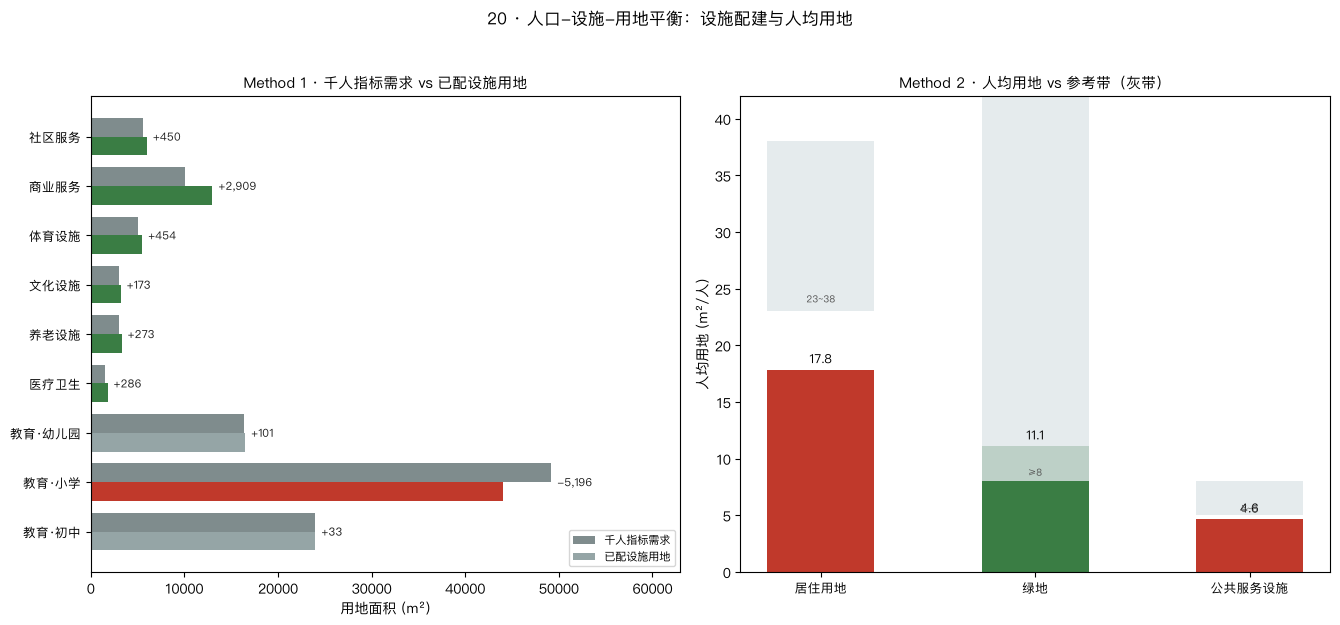

In [7]:
# --- figure 1: Method 1 facility balance + Method 2 per-capita bands ----
m1 = thousand_person_index(pop_est, REFERENCE_INDICATORS,
                           provided_land=PROVIDED_FACILITY_LAND)
m2 = per_capita_balance(land_areas, pop_est)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 6.2))

keys = list(REFERENCE_INDICATORS)
labels = [REFERENCE_INDICATORS[k]["zh"] for k in keys]
y = np.arange(len(keys))
req = [m1["rows"][k]["required"] for k in keys]
prov = [m1["rows"][k]["provided"] for k in keys]
prov_colors = ["#c0392b" if m1["rows"][k]["status"] == "deficit"
               else ("#3a7d44" if m1["rows"][k]["status"] == "surplus"
                     else "#95a5a6")
               for k in keys]
ax1.barh(y + 0.19, req, 0.38, label="千人指标需求", color="#7f8c8d")
ax1.barh(y - 0.19, prov, 0.38, label="已配设施用地", color=prov_colors)
for i, k in enumerate(keys):
    b = m1["rows"][k]["balance"]
    ax1.text(max(req[i], prov[i]) + 650, i, f"{b:+,.0f}",
             va="center", fontsize=8, color="#1a1a1a")
ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel("用地面积 (m²)")
ax1.set_title("Method 1 · 千人指标需求 vs 已配设施用地", fontsize=10.5)
ax1.legend(fontsize=8, loc="lower right")
ax1.set_xlim(0, max(max(req), max(prov)) * 1.28)

x = np.arange(len(m2["rows"]))
for i, r in enumerate(m2["rows"]):
    color = "#c0392b" if r["status"] == "violation" else "#3a7d44"
    ax2.bar(i, r["per_capita"], 0.5, color=color)
    ax2.text(i, r["per_capita"] + 0.6, f"{r['per_capita']:.1f}",
             ha="center", fontsize=9)
# 参考带：居住 23-38, 绿地 >=8, 设施 5-8
ax2.add_patch(Rectangle((-0.25, 23.0), 0.5, 15.0, facecolor="#dfe6e9",
                        edgecolor="none", alpha=0.8))
ax2.add_patch(Rectangle((0.75, 8.0), 0.5, 34.0, facecolor="#dfe6e9",
                        edgecolor="none", alpha=0.8))
ax2.add_patch(Rectangle((1.75, 5.0), 0.5, 3.0, facecolor="#dfe6e9",
                        edgecolor="none", alpha=0.8))
ax2.text(0, 23.8, "23~38", fontsize=7, ha="center", color="#555")
ax2.text(1, 8.5, "≥8", fontsize=7, ha="center", color="#555")
ax2.text(2, 5.3, "5~8", fontsize=7, ha="center", color="#555")
ax2.set_xticks(x)
ax2.set_xticklabels([r["zh"] for r in m2["rows"]], fontsize=9)
ax2.set_ylabel("人均用地 (m²/人)")
ax2.set_ylim(0, 42)
ax2.set_title("Method 2 · 人均用地 vs 参考带（灰带）", fontsize=10.5)

fig.suptitle("20 · 人口-设施-用地平衡：设施配建与人均用地", fontsize=12, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUTS / "20-closure-facility-balance.png", dpi=200,
            bbox_inches="tight")
plt.show()

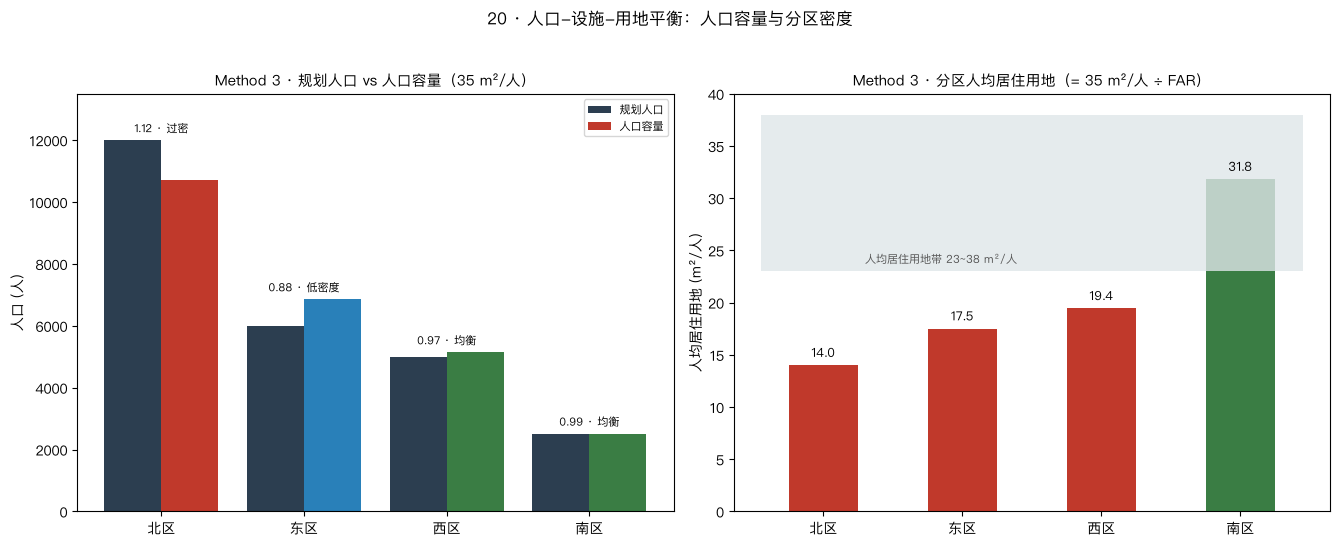

In [8]:
# --- figure 2: Method 3 zone capacity + zone per-capita residential land --
m3 = capacity_balance(ZONES, per_capita_floor=PER_CAPITA_FLOOR)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4))

names = [z["name"] for z in ZONES]
x = np.arange(len(names))
planned = [m3["zones"][n]["planned"] for n in names]
caps = [m3["zones"][n]["capacity"] for n in names]
vcolors = {"over_density": "#c0392b", "under_density": "#2980b9",
           "balanced": "#3a7d44"}
ax1.bar(x - 0.2, planned, 0.4, label="规划人口", color="#2c3e50")
ax1.bar(x + 0.2, caps, 0.4, label="人口容量",
        color=[vcolors[m3["zones"][n]["verdict"]] for n in names])
for xi, n in zip(x, names):
    z = m3["zones"][n]
    ax1.text(xi, max(z["planned"], z["capacity"]) + 260,
             f"{z['ratio']:.2f} · {VZH[z['verdict']]}",
             ha="center", fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(names)
ax1.set_ylabel("人口 (人)")
ax1.set_ylim(0, 13500)
ax1.set_title("Method 3 · 规划人口 vs 人口容量（35 m²/人）", fontsize=10.5)
ax1.legend(fontsize=8)

pc_land = [z["land"] / z["capacity"] for z in m3["zones"].values()]
for i, (n, pc) in enumerate(zip(names, pc_land)):
    color = "#c0392b" if not (23.0 <= pc <= 38.0) else "#3a7d44"
    ax2.bar(i, pc, 0.5, color=color)
    ax2.text(i, pc + 0.8, f"{pc:.1f}", ha="center", fontsize=9)
ax2.add_patch(Rectangle((-0.45, 23.0), len(names) - 0.1, 15.0,
                        facecolor="#dfe6e9", edgecolor="none", alpha=0.8))
ax2.text(0.3, 23.8, "人均居住用地带 23~38 m²/人", fontsize=8, color="#555")
ax2.set_xticks(x)
ax2.set_xticklabels(names)
ax2.set_ylabel("人均居住用地 (m²/人)")
ax2.set_ylim(0, 40)
ax2.set_title("Method 3 · 分区人均居住用地（= 35 m²/人 ÷ FAR）",
              fontsize=10.5)

fig.suptitle("20 · 人口-设施-用地平衡：人口容量与分区密度", fontsize=12, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUTS / "20-closure-zone-capacity.png", dpi=200,
            bbox_inches="tight")
plt.show()

## 4. Comparison and Conclusions 三方法对比

| 方法 | 输入 | 单元 | 输出 | 视角 |
|---|---|---|---|---|
| M1 千人指标 | 人口×千人指标 vs 已配用地 | 设施类别 | 盈余/缺口 | 设施配建数量 |
| M2 人均用地 | 用地汇总 ÷ 人口 | 用地类别 | 达标/违带 | 用地结构 |
| M3 容量 | 用地×FAR÷人均面积 vs 规划 | 片区 | 过密/低密度/均衡 | 人口规模与密度 |

三方法共享同一个人口基准（M1 估计值），结果可直接对账：

- 若 M1 小学缺口与 M2 设施人均偏低同时出现 → 设施总量和结构双缺口；
- 若 M3 过密片区与 M2 居住用地违带同时出现 → 高层高密度是共同原因。

In [9]:
# ── 汇总：三种方法闭合校验 (B-04) ──────────────────────────────
verdict = check_population_balance(
    land_areas, ZONES, provided_land=PROVIDED_FACILITY_LAND,
    planned_population=planned_pop)
print(f"结论: {verdict['verdict']}  "
      f"(估计人口 {verdict['estimated_population']:,.0f} / "
      f"规划人口 {verdict['planned_population']:,.0f})")
print()
print("—— 需调整项 ——")
for f in verdict["findings"]:
    print("  !", f)
print()
print("—— 富余提示 ——")
for n in verdict["notes"]:
    print("  +", n)

summary = {
    "target": "B-04",
    "verdict": verdict["verdict"],
    "estimated_population": round(verdict["estimated_population"], 1),
    "planned_population": verdict["planned_population"],
    "findings": verdict["findings"],
    "notes": verdict["notes"],
    "method1_totals": {k: round(verdict["method1"][k], 1)
                       for k in ("total_required", "total_provided",
                                 "total_balance")},
    "method2_per_capita": {r["category"]: round(r["per_capita"], 2)
                           for r in verdict["method2"]["rows"]},
    "method3": {name: {"capacity": round(z["capacity"], 1),
                       "planned": z["planned"],
                       "ratio": round(z["ratio"], 3),
                       "verdict": z["verdict"]}
                for name, z in verdict["method3"]["zones"].items()},
}
with open(OUTPUTS / "20-closure-summary.json", "w") as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2)
print()
print("saved:", OUTPUTS / "20-closure-summary.json")

结论: REVISE  (估计人口 25,229 / 规划人口 25,500)

—— 需调整项 ——
  ! M1 教育·小学: 缺口 -5,196 m²
  ! M2 居住用地 17.8 m²/人 低于下限 23.0~38.0 m²/人
  ! M2 公共服务设施 4.6 m²/人 低于下限 5.0~8.0 m²/人
  ! M3 北区: over_density (规划/容量 = 1.12)
  ! M3 东区: under_density (规划/容量 = 0.88)

—— 富余提示 ——
  + M1 医疗卫生: 富余 +286 m²
  + M1 养老设施: 富余 +273 m²
  + M1 文化设施: 富余 +173 m²
  + M1 体育设施: 富余 +454 m²
  + M1 商业服务: 富余 +2,909 m²
  + M1 社区服务: 富余 +450 m²

saved: /Users/lijia/Projects/urban-spatial-tooling/outputs/20-closure-summary.json


### 结论

1. **闭合恒等式**：`人口 = 居住用地 × FAR ÷ 人均建筑面积`。本场地
   估计人口 25,229 人 vs 规划 25,500 人（+1.1%）—— 总体自洽；
   但恒等式拆开看，三个环节各有断裂。
2. **M1 结构缺口**：设施总量仅差 -0.4%，但 小学缺口 -5,196 m²
   （-10.6%）、商业富余 +2,909 m² —— 只看总量会漏掉结构问题。
   千人指标的价值在类别级对账。
3. **M2 高层高密度矛盾**：人均居住用地 17.8 m²/人 < 23 m²/人 下限；
   绿地 11.1 m²/人 达标；设施 4.65 m²/人 略低于 5 m²/人。高层片区
   （北区/东区）人均居住用地仅 14.0-17.5 m²/人，多层片区（南区）31.8
   达标 —— "人均建筑面积 35 m² × FAR>1.8"与 23-38 居住用地带天然冲突，
   是密度决策的核心权衡。
4. **M3 局部失衡**：北区过密（规划/容量 1.12），东区低密度（0.88）；
   全区合计 1.01 均衡 —— 局部矛盾在平均中消失，必须按片区检查。
5. **参数敏感（C 类）**：千人指标、35 m²/人、23-38 / ≥8 / 5-8 参考带、
   ±10% 容差均为参考值；正式使用须以 GB 50180-2018 原文数值分圈层
   叠加，并与规划主管部门标定后写入 assumptions.json。

**References**
- GB 50180-2018《城市居住区规划设计标准》表5.0.3 配套设施控制指标
  （通称"千人指标"，配套设置要求见附录B；旧版 GB 50180-93 中位于附录A）
- GB 50180-2018 条文说明 4.0.2 / 4.0.3（人均住房建筑面积 35 m² 测算
  基准）、5.0.3（学校规模、派出所 32~40 m²/千人 等锚点）